# 🟢 NOTEBOOK 05 — EfficientNetB0 Transfer Learning
## Objectifs
Même structure que ResNet50 mais avec EfficientNetB0 :
plus léger (5.3M params vs 25.6M) et souvent plus précis.

> **Prérequis :** avoir exécuté `02_preprocessing.ipynb`

## 1. Imports & config

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE
import os, pickle, json, warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

PROC_DIR    = "../data/processed/"
OUT_MODELS  = "../outputs/models/"
OUT_PLOTS   = "../outputs/plots/"
OUT_RESULTS = "../outputs/results/"

with open(PROC_DIR + "config.pkl", "rb") as f:
    cfg = pickle.load(f)

IMG_SIZE    = cfg["IMG_SIZE"]
N_CLASSES   = cfg["N_CLASSES"]
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)
print(f"✅ Config : IMG_SIZE={IMG_SIZE} | N_CLASSES={N_CLASSES}")


✅ Config : IMG_SIZE=(96, 96) | N_CLASSES=7


## 2. Données

In [2]:
X_train = np.load(PROC_DIR + "X_train.npy")
X_val   = np.load(PROC_DIR + "X_val.npy")
X_test  = np.load(PROC_DIR + "X_test.npy")
y_train = np.load(PROC_DIR + "y_train.npy")
y_val   = np.load(PROC_DIR + "y_val.npy")
y_test  = np.load(PROC_DIR + "y_test.npy")
CLASS_NAMES = np.load(PROC_DIR + "class_names.npy", allow_pickle=True)

assert X_train.shape[1:] == INPUT_SHAPE, f"Shape mismatch : {X_train.shape[1:]} ≠ {INPUT_SHAPE}"
print(f"✅ Données OK : X_train={X_train.shape}")


✅ Données OK : X_train=(682, 96, 96, 3)


## 3. Modèle EfficientNetB0

In [3]:
def build_efficientnet(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape, name="input_image")
    
    # EfficientNet attend des pixels [0,255]
    x = layers.Rescaling(255.0)(inputs)
    
    base = EfficientNetB0(include_top=False, weights="imagenet",
                           input_tensor=x, pooling=None)
    base.trainable = False  # Phase 1 : gelé
    
    features = layers.GlobalAveragePooling2D(name="feature_vector")(base.output)
    
    x = layers.Dense(256, activation="relu")(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="predictions")(x)
    
    return keras.Model(inputs, outputs, name="EfficientNetB0_TL"), base

model, base_model = build_efficientnet(INPUT_SHAPE, N_CLASSES)
print(f"Params totaux    : {model.count_params():,}")
print(f"(ResNet50 avait  : ~25 600 000 params)")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 260s 16us/step
Params totaux    : 4,380,330
(ResNet50 avait  : ~25 600 000 params)


## 4. Phase 1 — Feature Extraction

In [4]:
BATCH = 32
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_fe = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=20, batch_size=BATCH,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6,
                                       restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                           patience=3, verbose=1),
    ], verbose=1
)
print(f"Phase 1 → Best val_accuracy : {max(history_fe.history['val_accuracy'])*100:.2f}%")


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 655ms/step - accuracy: 0.5587 - loss: 1.4360 - val_accuracy: 0.7722 - val_loss: 0.7788 - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 454ms/step - accuracy: 0.8724 - loss: 0.3472 - val_accuracy: 0.7785 - val_loss: 0.6752 - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step - accuracy: 0.9560 - loss: 0.1597 - val_accuracy: 0.8291 - val_loss: 0.6362 - learning_rate: 0.0010
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 312ms/step - accuracy: 0.9809 - loss: 0.0977 - val_accuracy: 0.8228 - val_loss: 0.6042 - learning_rate: 0.0010
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 359ms/step - accuracy: 0.9883 - loss: 0.0603 - val_accuracy: 0.8228 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 383ms/step - accuracy: 0.9956 - loss: 0.0457 - val_accuracy: 0.8038 - val_loss: 0.5746 - learning_rate: 0.0010
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - accuracy: 0.9985 - loss: 0.0370

## 5. Phase 2 — Fine-tuning

In [5]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_ft = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=20, batch_size=BATCH,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6,
                                       restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(OUT_MODELS + "efficientnet.keras",
                                         monitor="val_accuracy", save_best_only=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                           patience=3, verbose=1),
    ], verbose=1
)
print(f"Phase 2 → Best val_accuracy : {max(history_ft.history['val_accuracy'])*100:.2f}%")


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.7944 - loss: 0.5785
Epoch 1: val_accuracy improved from None to 0.81646, saving model to ../outputs/models/efficientnet.keras

Epoch 1: finished saving model to ../outputs/models/efficientnet.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 730ms/step - accuracy: 0.8006 - loss: 0.5703 - val_accuracy: 0.8165 - val_loss: 0.5859 - learning_rate: 1.0000e-05
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8465 - loss: 0.4428
Epoch 2: val_accuracy did not improve from 0.81646
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 424ms/step - accuracy: 0.8196 - loss: 0.5000 - val_accuracy: 0.8165 - val_loss: 0.6148 - learning_rate: 1.0000e-05
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8582 - loss: 0.3975
Epoch 3: val_accuracy did not improve from 0.81646
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 462ms/step - accuracy: 0.8460 - loss: 0.4446 - val_accuracy: 0.8165 - val_loss: 0.6465 - learning_rate: 1.0000e-05
Epoch 4/20
22/22 ━━━━━━━━

## 6. Courbes + Évaluation + Features + Sauvegarde

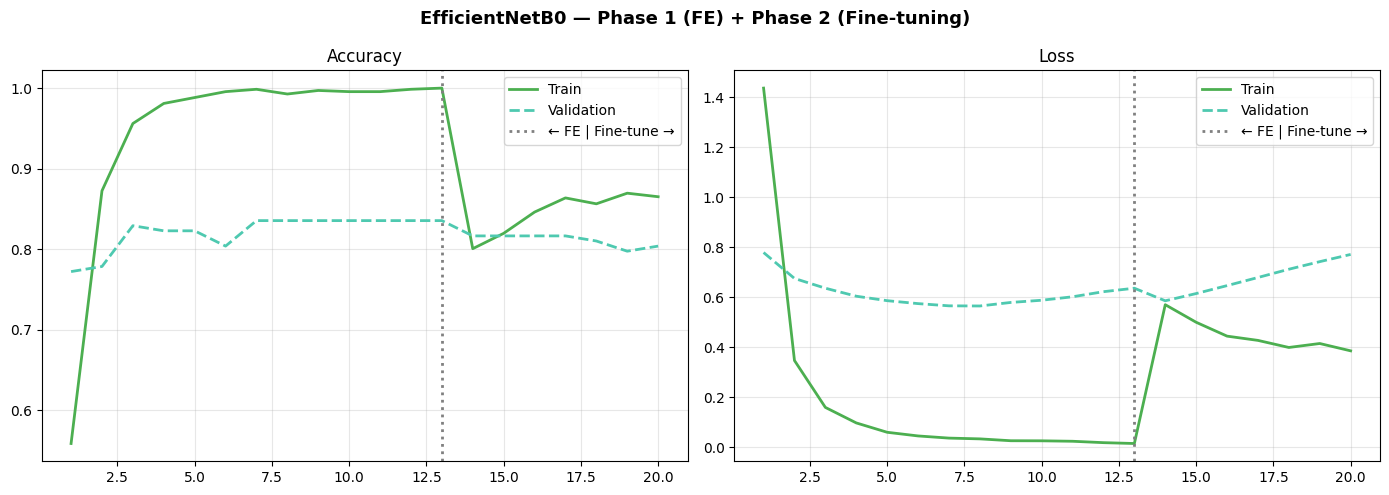

In [6]:
acc  = history_fe.history["accuracy"]     + history_ft.history["accuracy"]
vacc = history_fe.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss = history_fe.history["loss"]         + history_ft.history["loss"]
vloss= history_fe.history["val_loss"]     + history_ft.history["val_loss"]
ep1  = len(history_fe.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EfficientNetB0 — Phase 1 (FE) + Phase 2 (Fine-tuning)", fontsize=13, fontweight="bold")
for ax, tr, vl, title in zip(axes, [acc,loss], [vacc,vloss], ["Accuracy","Loss"]):
    ep = range(1, len(tr)+1)
    ax.plot(ep, tr, label="Train",      color="#4CAF50", lw=2)
    ax.plot(ep, vl, label="Validation", color="#4EC9B0", lw=2, ls="--")
    ax.axvline(ep1, color="gray", ls=":", lw=2, label="← FE | Fine-tune →")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_PLOTS + "05_curves_efficientnet.png", dpi=150, bbox_inches="tight")
plt.show()


Test Accuracy : 79.05%

                            precision    recall  f1-score   support

                 Baby Care       0.77      0.57      0.65        30
  Beauty and Personal Care       0.92      0.80      0.86        30
                 Computers       0.71      0.73      0.72        30
Home Decor & Festive Needs       0.74      0.77      0.75        30
           Home Furnishing       0.74      0.83      0.78        30
          Kitchen & Dining       0.85      0.93      0.89        30
                   Watches       0.82      0.90      0.86        30

                  accuracy                           0.79       210
                 macro avg       0.79      0.79      0.79       210
              weighted avg       0.79      0.79      0.79       210



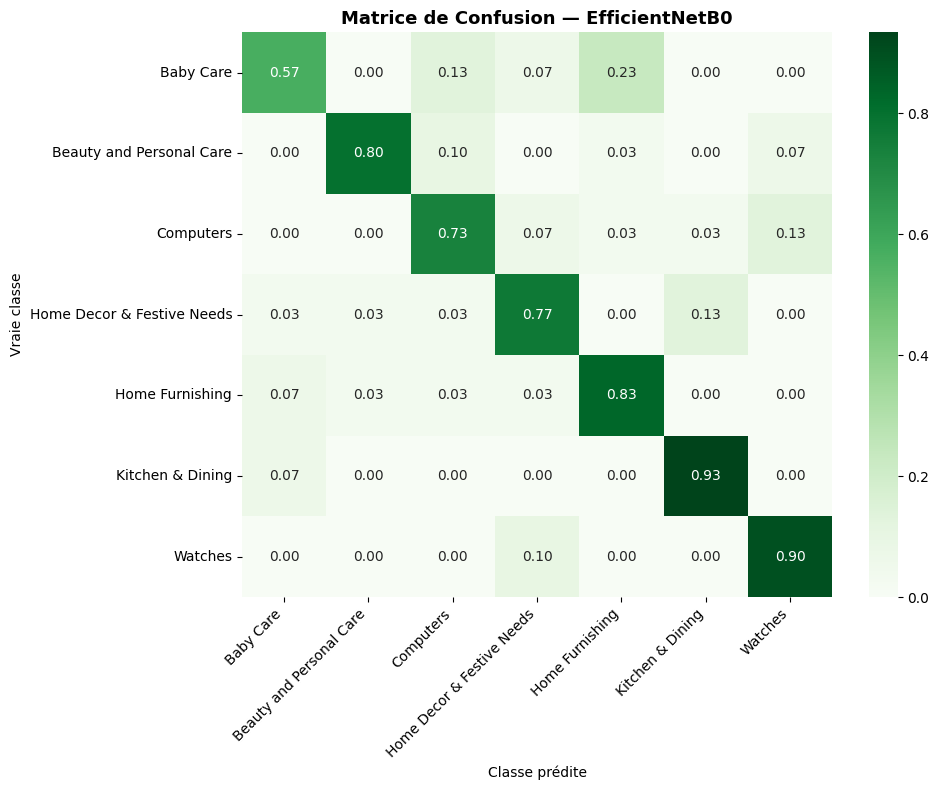

In [7]:
# Évaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm.astype(float)/cm.sum(axis=1)[:,np.newaxis], annot=True, fmt=".2f",
            cmap="Greens", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Matrice de Confusion — EfficientNetB0", fontsize=13, fontweight="bold")
ax.set_ylabel("Vraie classe"); ax.set_xlabel("Classe prédite")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(OUT_PLOTS + "05_cm_efficientnet.png", dpi=150, bbox_inches="tight")
plt.show()


22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 391ms/step
Features EfficientNet : 1280-dim | 💾 sauvegardées


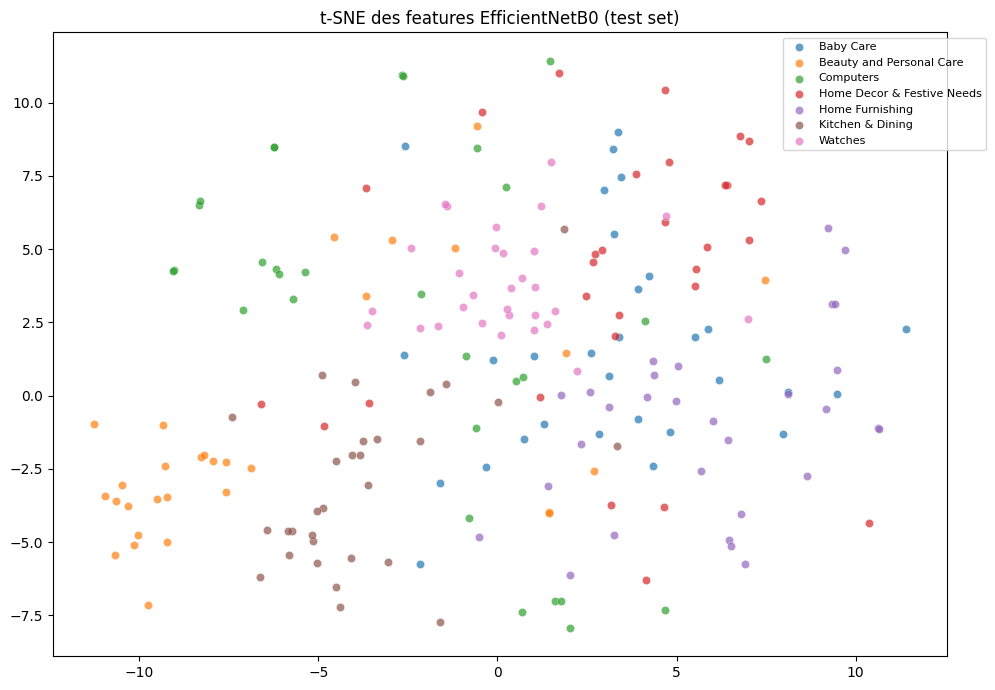

In [9]:
# Extraction de features
fe = keras.Model(inputs=model.input,
                 outputs=model.get_layer("feature_vector").output,
                 name="efficientnet_fe")

features_train = fe.predict(X_train, batch_size=32, verbose=1)
features_val   = fe.predict(X_val,   batch_size=32, verbose=0)
features_test  = fe.predict(X_test,  batch_size=32, verbose=0)

np.save(PROC_DIR + "features_train_efficientnet.npy", features_train)
np.save(PROC_DIR + "features_val_efficientnet.npy",   features_val)
np.save(PROC_DIR + "features_test_efficientnet.npy",  features_test)
print(f"Features EfficientNet : {features_train.shape[1]}-dim | 💾 sauvegardées")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb  = tsne.fit_transform(features_test)
fig, ax = plt.subplots(figsize=(10, 7))
for i in range(N_CLASSES):
    mask = (y_test == i)
    ax.scatter(emb[mask,0], emb[mask,1], label=CLASS_NAMES[i],
               color=plt.cm.tab10.colors[i], alpha=0.7, s=35,
               edgecolors="white", linewidths=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
ax.set_title("t-SNE des features EfficientNetB0 (test set)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_PLOTS + "05_tsne_efficientnet.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
results_en = {
    "model":    "EfficientNetB0 (TL)",
    "accuracy": round(float(test_acc), 4),
    "f1_score": round(float(f1_score(y_test, y_pred, average="weighted")), 4),
    "history":  {"accuracy":[float(v) for v in acc],"val_accuracy":[float(v) for v in vacc],
                 "loss":[float(v) for v in loss],"val_loss":[float(v) for v in vloss]}
}
with open(OUT_RESULTS + "results_efficientnet.json", "w") as f:
    json.dump(results_en, f, indent=2)

print("="*55)
print("  ✅ NOTEBOOK 05 TERMINÉ — EfficientNetB0")
print("="*55)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print("\n→ Exécuter ensuite : 06_comparaison.ipynb")


  ✅ NOTEBOOK 05 TERMINÉ — EfficientNetB0
  Test Accuracy : 79.05%

→ Exécuter ensuite : 06_comparaison.ipynb
